# SGCN — paper-style baseline (raw RGB+Gabor+Sobel features)

Spatial Graph Convolutional Network from *Graph-Based Two-Three Wheeler Classification in Unconstrained Indian Roads* (ITSC 2024).

- **Node features:** raw stacked features (L1: RGB+Gabor+Sobel; L2/L3: RGB+Gabor) per [README.md](FGVD_Graph_Handover/README.md).
- **Edge weights:** computed dynamically per crop using the Gaussian kernel `exp(-||RGB_u-RGB_v||²/2σ²)` over the skeleton connectivity. The deprecated shared `master_grid_adj.npz` is **not** used.
- **Tail-merge** is auto-enabled for L2/L3 via `fgvd_utils.run_experiment` (default: `tail_merge_min=20`). L2/L3 train flat by default.

Each level cell calls `run_experiment` and produces its own loss/accuracy plots inline.

In [2]:
from pathlib import Path
import importlib
import warnings; warnings.filterwarnings('ignore')

import fgvd_utils
fgvd_utils = importlib.reload(fgvd_utils)
ExperimentConfig = fgvd_utils.ExperimentConfig
run_experiment = fgvd_utils.run_experiment

CKPT_ROOT = Path('checkpoints')
PLOT_ROOT = Path('plots')

## L1 — vehicle type (7 classes; flat softmax)


=== SGCN | L1 | raw | hierarchical=False | tail_min=None ===
Samples: train=15702 val=3857 test=4891 | classes=7
AMP mixed precision: enabled
Resumed from checkpoints/sgcn/raw/L1_all/last.pt (epoch 8).
Epoch 009 | train_acc=0.5781 val_acc=0.5613 | train_loss=1.4039 val_loss=1.4635
Epoch 010 | train_acc=0.5794 val_acc=0.5795 | train_loss=1.4079 val_loss=1.4026
Epoch 015 | train_acc=0.5986 val_acc=0.5966 | train_loss=1.3698 val_loss=1.3559
Epoch 020 | train_acc=0.6022 val_acc=0.6165 | train_loss=1.3562 val_loss=1.3166
Epoch 025 | train_acc=0.6092 val_acc=0.6119 | train_loss=1.3274 val_loss=1.3365
Epoch 030 | train_acc=0.6165 val_acc=0.6375 | train_loss=1.3167 val_loss=1.2852
Epoch 035 | train_acc=0.6213 val_acc=0.6388 | train_loss=1.3048 val_loss=1.2759
Epoch 040 | train_acc=0.6244 val_acc=0.6142 | train_loss=1.2887 val_loss=1.3258
Epoch 045 | train_acc=0.6308 val_acc=0.6209 | train_loss=1.2830 val_loss=1.2979
Epoch 050 | train_acc=0.6374 val_acc=0.6484 | train_loss=1.2710 val_loss=1.28

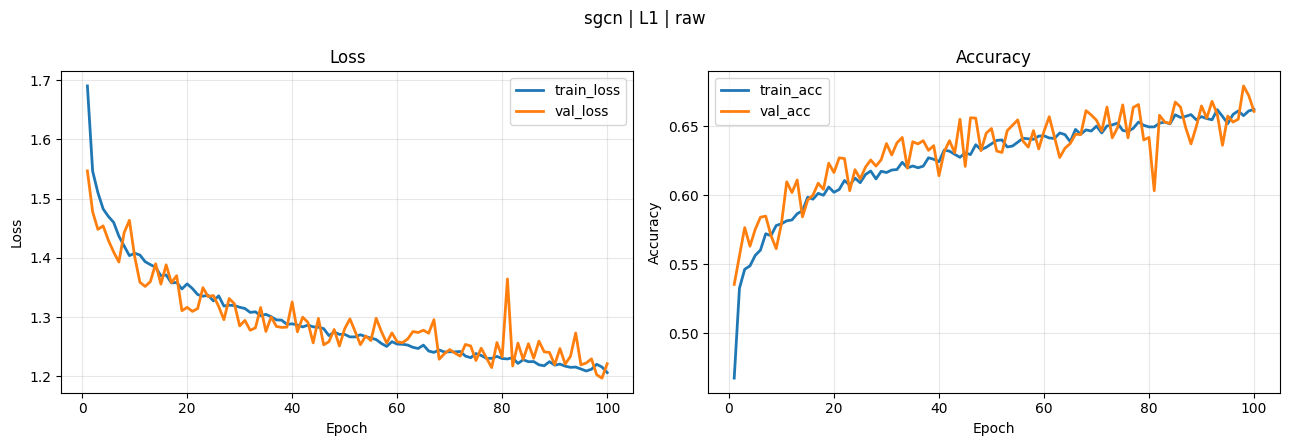

{'loss': 0.9129320332253791,
 'acc': 0.685544878347986,
 'macro_f1': 0.5743767270834047,
 'weighted_f1': 0.6706286073286768,
 'top1_acc': 0.685544878347986,
 'top3_acc': 0.9325291351461868,
 'top5_acc': 0.9795542833776324,
 'val_acc_best': 0.6792844179414053}

In [3]:
cfg_l1 = ExperimentConfig(
    method='sgcn', level='L1', feature_source='raw',
    epochs=100, batch_size=32, lr=1e-3,
    hidden_dim=64, num_layers=2, dropout=0.5,
    use_logit_adjustment=False,
)
out_l1 = run_experiment(cfg_l1, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l1['metrics']

## L2 — manufacturer (flat + tail-merge)


=== SGCN | L2 | raw | hierarchical=False | tail_min=20 ===
Samples: train=15702 val=3857 test=4891 | classes=46
Tail-merge: kept 41/59 classes | coverage train=0.991 val=0.990 test=0.992
AMP mixed precision: enabled
Epoch 001 | train_acc=0.1574 val_acc=0.2292 | train_loss=4.2268 val_loss=4.0728
Epoch 005 | train_acc=0.2042 val_acc=0.2287 | train_loss=3.9353 val_loss=3.9029
Epoch 010 | train_acc=0.2125 val_acc=0.2577 | train_loss=3.8581 val_loss=3.8719
Epoch 015 | train_acc=0.2149 val_acc=0.2590 | train_loss=3.8191 val_loss=3.7926
Epoch 020 | train_acc=0.2154 val_acc=0.2634 | train_loss=3.7840 val_loss=3.7715
Epoch 025 | train_acc=0.2226 val_acc=0.2593 | train_loss=3.7715 val_loss=3.7463
Epoch 030 | train_acc=0.2238 val_acc=0.2567 | train_loss=3.7543 val_loss=3.7421
Epoch 035 | train_acc=0.2249 val_acc=0.2738 | train_loss=3.7352 val_loss=3.7128
Epoch 040 | train_acc=0.2245 val_acc=0.2751 | train_loss=3.7220 val_loss=3.7047
Epoch 045 | train_acc=0.2295 val_acc=0.2834 | train_loss=3.7151

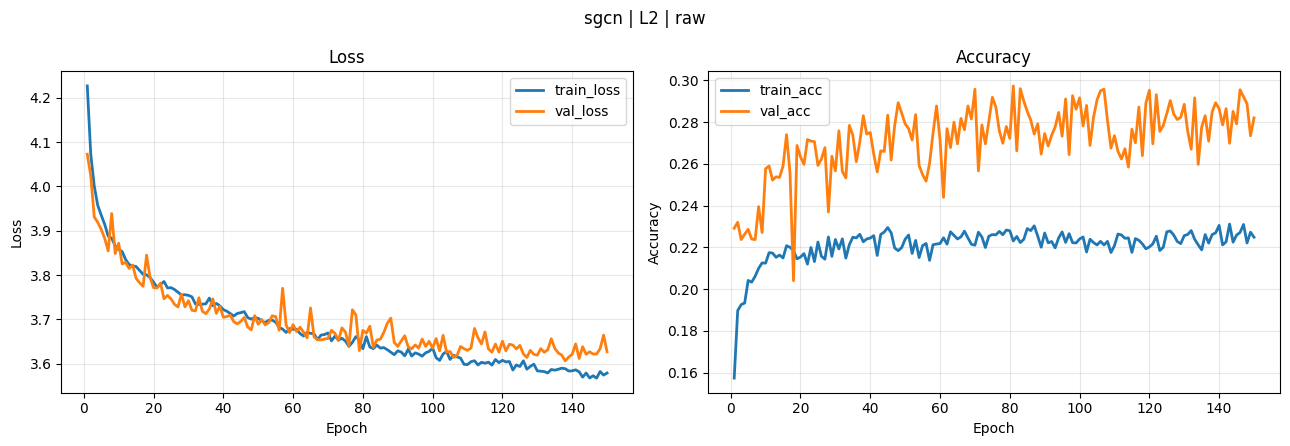

{'loss': 2.902857609941681,
 'acc': 0.2760171744019628,
 'macro_f1': 0.13830131300645912,
 'weighted_f1': 0.24711561715957472,
 'top1_acc': 0.2760171744019628,
 'top3_acc': 0.5197301165405848,
 'top5_acc': 0.6377019014516458,
 'val_acc_best': 0.29738138449572205}

In [4]:
cfg_l2 = ExperimentConfig(
    method='sgcn', level='L2', feature_source='raw',
    epochs=150, batch_size=32, lr=1e-3,
    hidden_dim=64, num_layers=2, dropout=0.5,
    hierarchical=False,
)
out_l2 = run_experiment(cfg_l2, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l2['metrics']

## L3 — model (flat + tail-merge)


=== SGCN | L3 | raw | hierarchical=False | tail_min=50 ===
Samples: train=15702 val=3857 test=4891 | classes=103
Tail-merge: kept 60/209 classes | coverage train=0.886 val=0.883 test=0.885
AMP mixed precision: enabled
Epoch 001 | train_acc=0.1426 val_acc=0.2043 | train_loss=4.4290 val_loss=4.2880
Epoch 005 | train_acc=0.1502 val_acc=0.1836 | train_loss=3.9899 val_loss=4.0309
Epoch 010 | train_acc=0.1511 val_acc=0.1434 | train_loss=3.8082 val_loss=3.9055
Epoch 015 | train_acc=0.1519 val_acc=0.1641 | train_loss=3.6846 val_loss=3.8371
Epoch 020 | train_acc=0.1493 val_acc=0.1729 | train_loss=3.6077 val_loss=3.7882
Epoch 025 | train_acc=0.1544 val_acc=0.1706 | train_loss=3.5341 val_loss=3.7794
Epoch 030 | train_acc=0.1633 val_acc=0.1779 | train_loss=3.4792 val_loss=3.7524
Epoch 035 | train_acc=0.1630 val_acc=0.1763 | train_loss=3.4193 val_loss=3.7668
Epoch 040 | train_acc=0.1675 val_acc=0.1846 | train_loss=3.3984 val_loss=3.7527
Epoch 045 | train_acc=0.1680 val_acc=0.1885 | train_loss=3.34

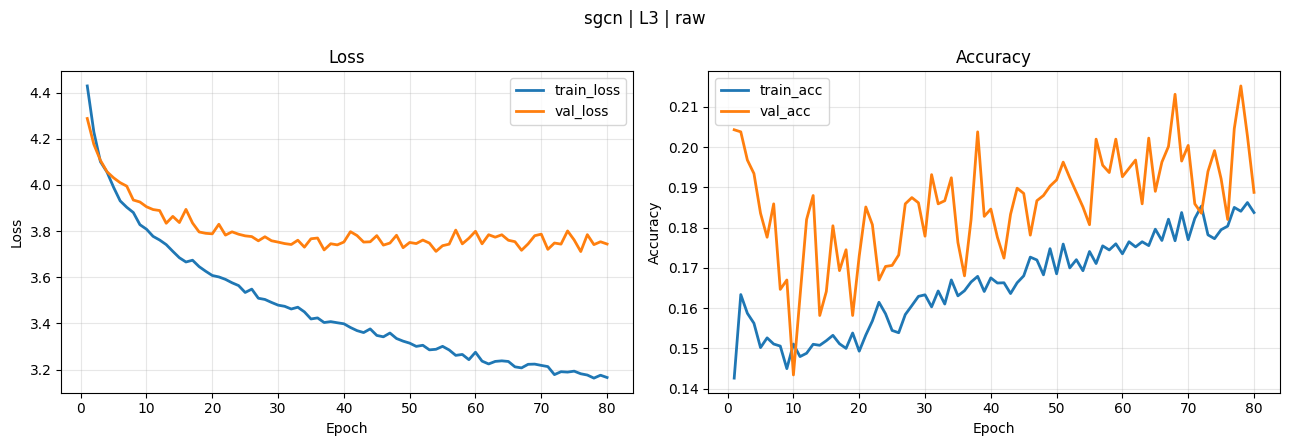

{'loss': 3.247979500863577,
 'acc': 0.19586996524228173,
 'macro_f1': 0.12305638756850618,
 'weighted_f1': 0.20278487884571011,
 'top1_acc': 0.19586996524228173,
 'top3_acc': 0.3764056430177878,
 'top5_acc': 0.4725005111429156,
 'val_acc_best': 0.21519315530204822}

In [7]:
cfg_l3 = ExperimentConfig(
    method='sgcn', level='L3', feature_source='raw',
    epochs=80, batch_size=16, lr=5e-4, weight_decay=1e-4,
    hidden_dim=128, num_layers=3, dropout=0.3,
    label_smoothing=0.0,
    tail_merge_min=50,
    hierarchical=False,
    resume=False,
)
out_l3 = run_experiment(cfg_l3, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l3['metrics']